# Experiment 1: Train ML Model and Deploy Model to File (PKL)

**Objective:**
- Train a Machine Learning model on the Bank Churn Classification Dataset
- Save the trained model using Pickle (.pkl file)
- Verify that the model loads correctly and produces predictions

**Dataset:** Bank_Churn_Classification_Dataset.csv

**Target Variable:** Churn (Binary Classification - 0: No Churn, 1: Churn)

## Step 1: Install Required Libraries

In [ ]:
# VIVA  Using sys.executable ensures pip installs to the correct virtual environment
# This prevents "ModuleNotFoundError" when running notebooks
# Key packages: pandas (data), sklearn (ML), matplotlib/seaborn (viz), pickle (serialization)
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn pickle5 joblib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## Step 2: Import Libraries

In [ ]:
# VIVA  Import all required libraries for data processing, ML, and visualization
# - pandas/numpy: data manipulation
# - sklearn: ML algorithms and preprocessing (LabelEncoder, StandardScaler, RandomForest)
# - pickle: serialize and save trained models for deployment
# - matplotlib/seaborn: visualize data distribution and model performance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 3: Load and Explore the Dataset

In [ ]:
# VIVA Load dataset and perform initial exploration
# - index_col=0 uses first column as row index (CustomerID)
# - Understanding data shape, types, and columns is critical before modeling
# - This dataset has 7 features + 1 target (Churn) with ~10K rows
# Load the dataset
df = pd.read_csv('Bank_Churn_Classification_Dataset.csv', index_col=0)

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
df.head(10)

Dataset Shape: (10000, 9)

Column Names:
['CustomerID', 'Gender', 'SeniorCitizen', 'Tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'Churn', 'TotalCharges']

Data Types:
CustomerID          int64
Gender             object
SeniorCitizen       int64
Tenure              int64
MonthlyCharges    float64
Contract           object
PaymentMethod      object
Churn               int64
TotalCharges      float64
dtype: object


,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35
5,5,Female,0,31,86.02,Month-to-month,Mailed check,1,2666.62
6,6,Male,1,44,47.08,One year,Bank transfer,0,2071.52
7,7,Male,1,68,44.37,Two year,Electronic check,0,3017.16
8,8,Male,0,48,45.66,One year,Electronic check,0,2191.68
9,9,Female,0,57,111.61,Two year,Credit card,0,6361.77


In [ ]:
# VIVA  Check data quality and class distribution
# - Missing values can break models - verify none exist
# - Class imbalance affects model performance - check Churn distribution
# - If classes are imbalanced (e.g. 80/20), consider stratified sampling or SMOTE
# Basic statistics
print("Dataset Info:")
df.info()
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nTarget Distribution:\n{df['Churn'].value_counts()}")
print(f"\nTarget Distribution (%):\n{df['Churn'].value_counts(normalize=True) * 100}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      10000 non-null  int64  
 1   Gender          10000 non-null  object 
 2   SeniorCitizen   10000 non-null  int64  
 3   Tenure          10000 non-null  int64  
 4   MonthlyCharges  10000 non-null  float64
 5   Contract        10000 non-null  object 
 6   PaymentMethod   10000 non-null  object 
 7   Churn           10000 non-null  int64  
 8   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 781.2+ KB

Missing Values:
CustomerID        0
Gender            0
SeniorCitizen     0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
Churn             0
TotalCharges      0
dtype: int64

Target Distribution:
Churn
0    7330
1    2670
Name: count, dtype: int64

Target Distribution (%):
Churn
0    73.3

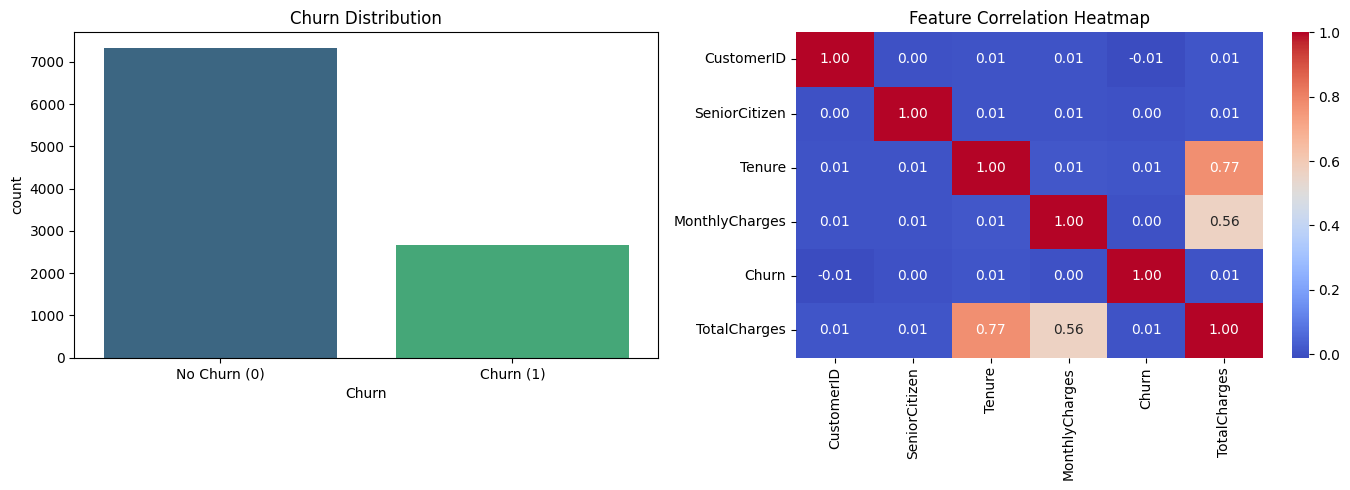

In [ ]:
#   Visualize target distribution and feature correlations
# - Churn countplot shows if dataset is balanced
# - Heatmap identifies correlated features (multicollinearity)
# - High correlation between features may require feature selection
# Visualize the target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn distribution
sns.countplot(x='Churn', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])

# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1], fmt='.2f')
axes[1].set_title('Feature Correlation Heatmap')
 
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [ ]:
# VIVA  Encode categorical variables for ML algorithms
# - ML models require numeric input - can't process 'Male' or 'Female' directly
# - LabelEncoder converts categories to integers (Male=0, Female=1)
# - CRITICAL: Save label_encoders dictionary for production use (to encode new data identically)
# - CustomerID is dropped as it's an identifier, not a predictive feature
# Drop CustomerID as it's not a feature
df_processed = df.drop('CustomerID', axis=1)

# Encode categorical variables
label_encoders = {}
categorical_cols = df_processed.select_dtypes(include=['object']).columns
print(f"Categorical columns: {categorical_cols.tolist()}")

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_processed.head()

Categorical columns: ['Gender', 'Contract', 'PaymentMethod']
Gender: {'Female': 0, 'Male': 1}
Contract: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
PaymentMethod: {'Bank transfer': 0, 'Credit card': 1, 'Electronic check': 2, 'Mailed check': 3}


,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,1,0,55,111.88,2,3,0,6153.40
1,0,1,36,58.70,2,2,0,2113.20
2,1,0,37,118.86,1,2,0,4397.82
3,1,1,14,96.14,0,3,1,1345.96
4,1,1,27,28.05,2,3,0,757.35


In [ ]:
#   Separate features (X) from target (y)
# - X contains all features used for prediction
# - y is what we want to predict (Churn: 0 or 1)
# - This separation is required for supervised learning
# Split features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Features shape: (10000, 7)
Target shape: (10000,)

Feature columns: ['Gender', 'SeniorCitizen', 'Tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod', 'TotalCharges']


In [ ]:
# VIVA  Split data into training and testing sets
# - 80% train, 20% test is standard split
# - stratify=y maintains class distribution in both sets (important for imbalanced data)
# - random_state=42 ensures reproducible splits
# - StandardScaler normalizes features (mean=0, std=1) - important for distance-based algorithms
# - Fit scaler on TRAIN only, then transform both (prevents data leakage)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")

Training set size: 8000
Testing set size: 2000

Feature scaling completed!


## Step 5: Train the Model

In [ ]:
# VIVA  Train RandomForest classifier
# - RandomForest is robust, handles non-linear relationships, less prone to overfitting
# - n_estimators=100: number of decision trees (more trees = better but slower)
# - max_depth=10: limit tree depth to prevent overfitting
# - n_jobs=-1: use all CPU cores for parallel training
# - random_state=42: reproducible results
# Train a Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)
print("Model training completed!")

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

Model training completed!


MODEL EVALUATION

Accuracy: 0.7325

Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1466
           1       0.00      0.00      0.00       534

    accuracy                           0.73      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.54      0.73      0.62      2000



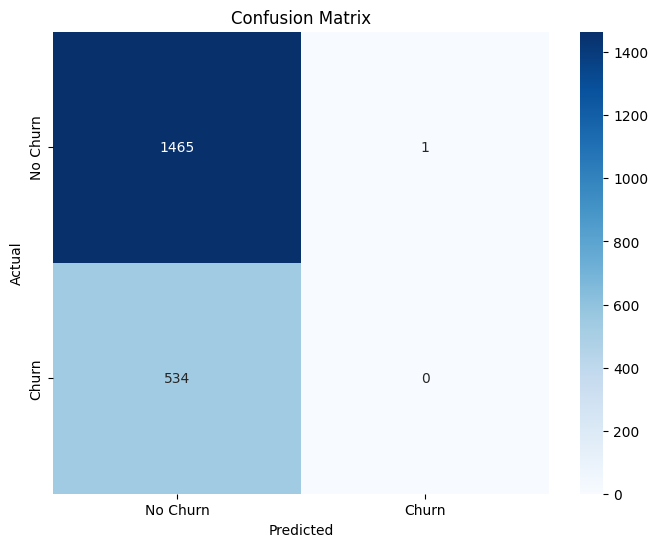

In [ ]:
# VIVA  Evaluate model performance on test data
# - Accuracy: overall correctness (but can be misleading for imbalanced data)
# - Classification report: precision, recall, F1-score per class
# - Confusion matrix: visualize True Positives, False Positives, etc.
# - For churn prediction, recall (catching actual churners) is often more important than precision
# Evaluate the model
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

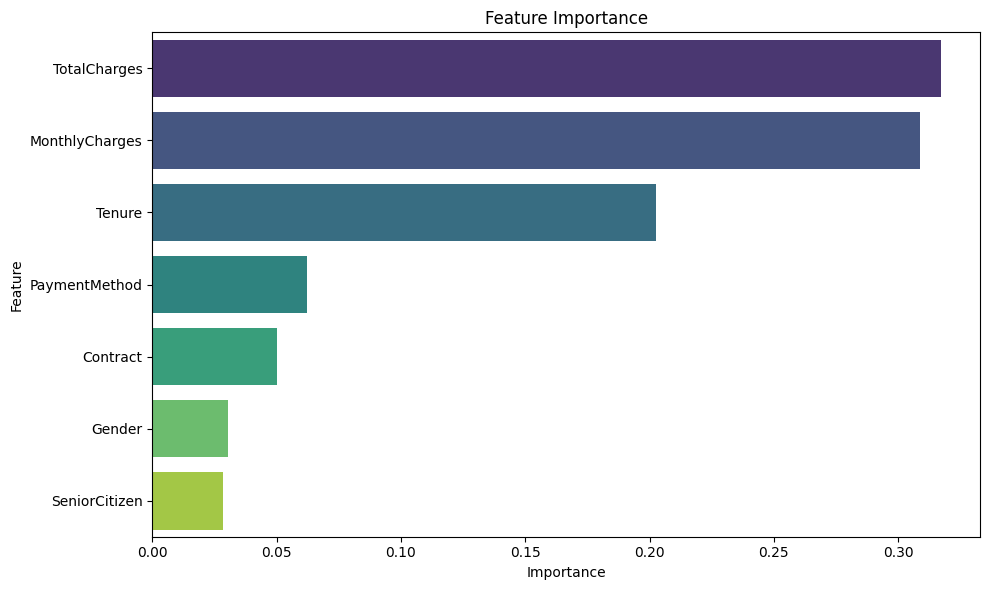

          Feature  Importance
6    TotalCharges    0.317057
3  MonthlyCharges    0.308643
2          Tenure    0.202654
5   PaymentMethod    0.062354
4        Contract    0.050052
0          Gender    0.030642
1   SeniorCitizen    0.028598


In [ ]:
# VIVA Analyze feature importance
# - Shows which features most influence churn prediction
# - Helps explain model decisions to business stakeholders
# - Can guide feature engineering and business strategy (e.g., focus on high-importance factors)
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

print(feature_importance)

## Step 6: Save Model Using Pickle (.pkl)

In [ ]:
# VIVA  Save all model artifacts for deployment
# - pickle serializes Python objects to binary files (.pkl)
# - Save model, scaler, label_encoders, feature_names separately
# - WHY? Production API needs exact same preprocessing as training
# - Without scaler/encoders, new data would have different scale/encoding = wrong predictions
# - This is MODEL DEPLOYMENT - making trained model reusable in production
# Create a directory for all model artifacts
os.makedirs('model_artifacts', exist_ok=True)

# Save the trained model
with open('model_artifacts/churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved to model_artifacts/churn_model.pkl")

# Save the scaler
with open('model_artifacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to model_artifacts/scaler.pkl")

# Save the label encoders
with open('model_artifacts/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("Label encoders saved to model_artifacts/label_encoders.pkl")

# Save feature names for later use
with open('model_artifacts/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)
print("Feature names saved to model_artifacts/feature_names.pkl")

# Verify files exist
for fname in os.listdir('model_artifacts'):
    fsize = os.path.getsize(f'model_artifacts/{fname}')
    print(f"  {fname}: {fsize / 1024:.2f} KB")

Model saved to model_artifacts/churn_model.pkl
Scaler saved to model_artifacts/scaler.pkl
Label encoders saved to model_artifacts/label_encoders.pkl
Feature names saved to model_artifacts/feature_names.pkl
  scaler.pkl: 0.78 KB
  label_encoders.pkl: 0.48 KB
  feature_names.pkl: 0.11 KB
  churn_model.pkl: 4342.62 KB


## Step 7: Verify Model Loading

In [ ]:
# VIVA  Verify model loading works correctly
# - This simulates what production API will do
# - pickle.load deserializes binary files back to Python objects
# - IMPORTANT: Verify loaded model has same type and behavior
# - This ensures deployment pipeline is correct
# Load the model back from pickle file
with open('model_artifacts/churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
print("Model loaded successfully!")
print(f"Model type: {type(loaded_model)}")

# Load the scaler
with open('model_artifacts/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
print(f"Scaler loaded successfully! Type: {type(loaded_scaler)}")

# Load the label encoders
with open('model_artifacts/label_encoders.pkl', 'rb') as f:
    loaded_encoders = pickle.load(f)
print(f"Label encoders loaded: {list(loaded_encoders.keys())}")

Model loaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Scaler loaded successfully! Type: <class 'sklearn.preprocessing._data.StandardScaler'>
Label encoders loaded: ['Gender', 'Contract', 'PaymentMethod']


In [ ]:
#  Validate loaded model produces identical predictions
# - np.array_equal checks if predictions match exactly
# - If False, serialization/deserialization has a problem
# - This is a critical test before deploying to production
# Verify predictions match
y_pred_loaded = loaded_model.predict(loaded_scaler.transform(X_test))

# Compare predictions from original and loaded model
predictions_match = np.array_equal(y_pred, y_pred_loaded)
print(f"Predictions from original and loaded model match: {predictions_match}")
print(f"Loaded model accuracy: {accuracy_score(y_test, y_pred_loaded):.4f}")

Predictions from original and loaded model match: True
Loaded model accuracy: 0.7325


In [ ]:
#  Test with a single sample input (simulates production API call)
# - Create sample data as dict (matches API JSON payload format)
# - Apply same preprocessing: encode categoricals → scale numerics
# - Get prediction (0/1) and probabilities
# - This demonstrates end-to-end inference pipeline
# Test with a sample input
sample_input = {
    'Gender': 'Male',
    'SeniorCitizen': 0,
    'Tenure': 30,
    'MonthlyCharges': 70.5,
    'Contract': 'One year',
    'PaymentMethod': 'Electronic check',
    'TotalCharges': 2115.0
}

# Preprocess the sample
sample_df = pd.DataFrame([sample_input])
for col in loaded_encoders:
    if col in sample_df.columns:
        sample_df[col] = loaded_encoders[col].transform(sample_df[col])

sample_scaled = loaded_scaler.transform(sample_df)
prediction = loaded_model.predict(sample_scaled)
prediction_proba = loaded_model.predict_proba(sample_scaled)

print(f"\nSample Input: {sample_input}")
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Confidence: No Churn={prediction_proba[0][0]:.4f}, Churn={prediction_proba[0][1]:.4f}")
print("\n✅ Model deployment to file verified successfully!")


Sample Input: {'Gender': 'Male', 'SeniorCitizen': 0, 'Tenure': 30, 'MonthlyCharges': 70.5, 'Contract': 'One year', 'PaymentMethod': 'Electronic check', 'TotalCharges': 2115.0}
Prediction: No Churn
Confidence: No Churn=0.7148, Churn=0.2852

✅ Model deployment to file verified successfully!
